In [34]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


In [43]:
df = pd.read_csv('dataset/spam.csv')

In [44]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [46]:
df.shape

(5572, 2)

In [47]:
df.describe() 

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [48]:
# check missing values
df.isnull().sum()

Category    0
Message     0
dtype: int64

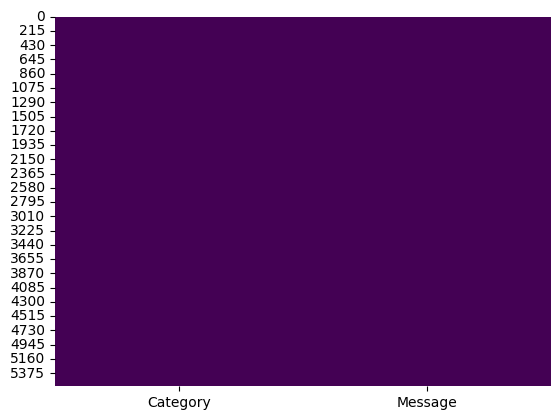

In [49]:
sns.heatmap(df.isnull(), cmap='viridis', cbar=False)
plt.show()

In [50]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [51]:
df['Category'].value_counts()/len (df)*100

Category
ham     86.593683
spam    13.406317
Name: count, dtype: float64

<BarContainer object of 2 artists>

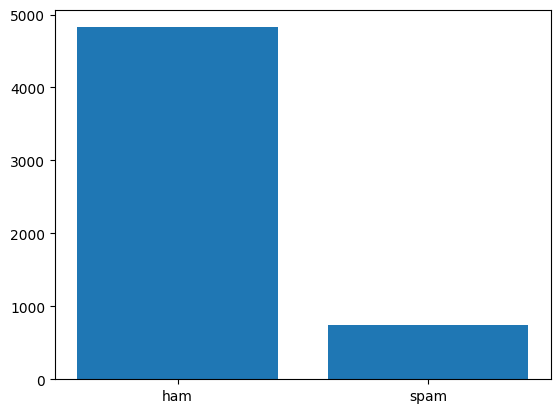

In [52]:
plt.bar(['ham','spam'],df['Category'].value_counts())

<Axes: >

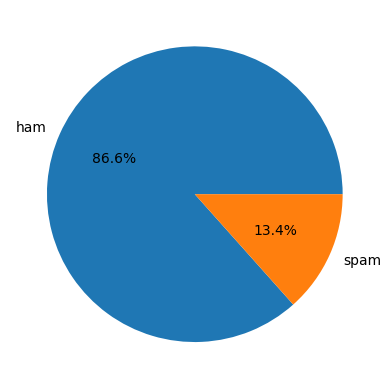

In [53]:
df['Category'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [54]:
df['Message']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str

In [55]:
df.duplicated(subset='Message').sum()

np.int64(415)

In [56]:
df.drop_duplicates(keep='first', inplace=True)

In [57]:
def lowerChange(text):
    return text.lower() 

df['Message']=df['Message'].apply(lowerChange)
df['Message']

0       go until jurong point, crazy.. available only ...
1                           ok lar... joking wif u oni...
2       free entry in 2 a wkly comp to win fa cup fina...
3       u dun say so early hor... u c already then say...
4       nah i don't think he goes to usf, he lives aro...
                              ...                        
5567    this is the 2nd time we have tried 2 contact u...
5568                 will ü b going to esplanade fr home?
5569    pity, * was in mood for that. so...any other s...
5570    the guy did some bitching but i acted like i'd...
5571                           rofl. its true to its name
Name: Message, Length: 5157, dtype: str

In [58]:
df['Category']=df['Category'].map({'ham':1,'spam':0})

In [59]:
df['Category'].value_counts()

Category
1    4516
0     641
Name: count, dtype: int64

In [60]:
X=df['Message']
y=df['Category']

In [61]:
X_train1,X_test1,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


df = pd.read_csv('dataset/spam.csv')

df.head()

df.info()

df.shape

df.describe() 

# check missing values
df.isnull().sum()

sns.heatmap(df.isnull(), cmap='viridis', cbar=False)
plt.show()

df['Category'].value_counts()
df['Category'].value_counts()/len (df)*100

plt.bar(['ham','spam'],df['Category'].value_counts())

df['Category'].value_counts().plot(kind='pie',autopct='%1.1f%%')

df['Message']

df.duplicated(subset='Message').sum()

df.drop_duplicates(keep='first', inplace=True)

def lowerChange(text):
    return text.lower() 

df['Message']=df['Message'].apply(lowerChange)
df['Message']

df['Category']=df['Category'].map({'ham':1,'spam':0})
df['Category'].value_counts()
X=df['Message']
y=df['Category']
https://www.kaggle.com/code/danishammar/spam-email-99-accuracy/notebook
# Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Fit the vectorizer on the training data and transform the training data
X_train = vectorizer.fit_transform(X_train1)

# Transform the test data using the same vectorizer
X_test = vectorizer.transform(X_test1)

def train_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision


#%%time
accuracy_scores = []
precision_scores = []

# Iterate over the items in the clfs dictionary
for name, model in models.items():
    current_accuracy, current_precision = train_classifier(model, X_train, y_train, X_test, y_test)
    rounded_accuracy = round(current_accuracy, 2)
    rounded_precision = round(current_precision, 2)
    
    print()
    print("For: ", name)
    print("Accuracy: ", rounded_accuracy)
    print("Precision: ", rounded_precision)

    accuracy_scores.append(rounded_accuracy)
    precision_scores.append(rounded_precision)



NameError: name 'models' is not defined